In [131]:
#Primero importamos las librerias que vamos a utilizar y damos la dirección del archivo
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os
os.chdir("/Users/AlanHDLR/Desktop")

In [133]:
# Despues abrimos el archivo y visualizamos los datos 
df = pd.read_excel("Mexico GDP.xlsx")
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


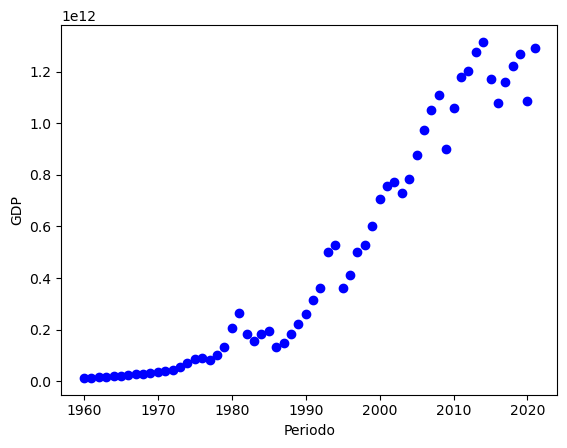

In [135]:
#Creamos un diagrama de dispersión para visualizar com se comportan los datos
cdf = df[['Periodo', 'GDP']]
plt.scatter(cdf.Periodo, cdf.GDP, color='blue')
plt.xlabel('Periodo')
plt.ylabel('GDP')
plt.show()

In [137]:
# Definimos el grupo de entrenamiento 
# Si aparece True el dato será contemplado para el grupo, por el contrario false no
msk = np.random.rand(len(df)) <= 0.80
msk

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True, False, False,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False])

In [139]:
#Grupo de entrenamiento
train = cdf[msk]
train

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10
5,1965,2.184000e+10
6,1966,2.432000e+10
7,1967,2.656000e+10
8,1968,2.936000e+10
9,1969,3.248000e+10


In [141]:
# Sacar el complemento (grupo de prueba)
test = cdf[~msk]
test

,Periodo,GDP
11,1971,3.920000e+10
18,1978,1.025000e+11
25,1985,1.952198e+11
27,1987,1.475407e+11
33,1993,5.007361e+11
34,1994,5.278132e+11
36,1996,4.109756e+11
43,2003,7.293363e+11
45,2005,8.774762e+11
60,2020,1.087118e+12


In [143]:
#Creamos un modelo de regresión lineal
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['Periodo']])
train_y = np.asanyarray(train[['GDP']])
regr.fit (train_x, train_y)

LinearRegression()

In [145]:
# Obtenemos los primero valores sobre los Coeficiente de pendiente e intercepto
print('Coeficiente de pendiente', regr.coef_)
print('Coeficiente de intercepto', regr.intercept_)

Coeficiente de pendiente [[2.39511781e+10]]
Coeficiente de intercepto [-4.71721456e+13]


# GDP = -4.70503112 + 2.38791031 * (Periodo)

Text(0, 0.5, 'GDP')

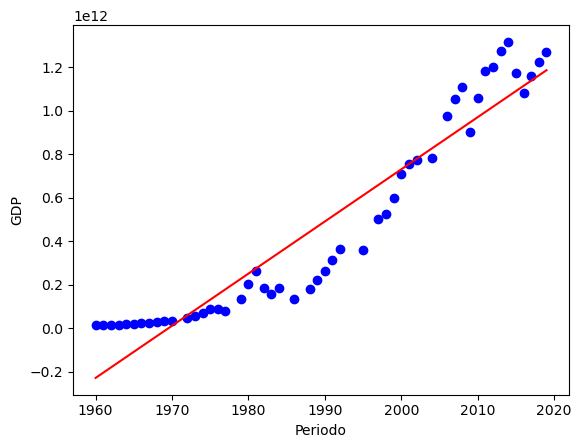

In [148]:
#Colocar la recta encima de los puntos 
plt.scatter(train.Periodo, train.GDP, color ='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r' )
plt.xlabel("Periodo")
plt.ylabel("GDP")

In [150]:
# Evaluación del modelo con los datos al azar
from sklearn.metrics import r2_score
test_x = np.asanyarray(test[['Periodo']])
test_y = np.asanyarray(test[['GDP']])
test_y_hat = regr.predict(test_x)

In [152]:
test_y_hat

array([[3.56264970e+10],
       [2.03284744e+11],
       [3.70942991e+11],
       [4.18845347e+11],
       [5.62552416e+11],
       [5.86503594e+11],
       [6.34405950e+11],
       [8.02064197e+11],
       [8.49966553e+11],
       [1.20923423e+12],
       [1.23318540e+12]])

In [154]:
test_y

array([[3.92000000e+10],
       [1.02500000e+11],
       [1.95219790e+11],
       [1.47540738e+11],
       [5.00736066e+11],
       [5.27813238e+11],
       [4.10975595e+11],
       [7.29336320e+11],
       [8.77476221e+11],
       [1.08711778e+12],
       [1.29303787e+12]])

In [156]:
# Calcular el valor absoluto de base de prueba contra los reales
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_hat - test_y)))
# Suma de residuales al cuadrado
print("Residuales sum of squares (MSE): %.2f" % np.mean((test_y_hat - test_y) ** 2))
# Valor de r2 al cuadrado
print("R2-score: %.2f" % r2_score(test_y_hat, test_y))

Mean absolute error: 107048142597.89
Residuales sum of squares (MSE): 17852998187150334754816.00
R2-score: 0.86


In [158]:
# Al intentar trabajar con los valores enteros, las tablas no podían contener todos los valores y eran bastante
# impresisas y muy variables por lo que decidí simplificar los valores del GDP además de utilizar la libreria "scipy.optimize"
# para poder tener una visualización más detallada de los datos y no solo la linea recta anterior

# Importamos una libreria que nos hacia falta
from scipy.optimize import curve_fit

# Definimos X como los periodos desde 1960 a 2021
periodo = np.arange(1960, 2022)

# Definimos Y como el GDP simplificado en Billones 
# (convertidos a billonesnos ayudara para tener una mejor estabilidad numérica y menos variables sueltas)
GDP_billones = np.array([
    13.04, 14.16, 15.20, 16.96, 20.08, 21.84, 23.92, 26.56, 29.36, 32.48, 35.20,
    39.20, 45.20, 55.28, 72.00, 88.60, 89.04, 81.81, 102.50, 134.56, 184.13,
    263.95, 184.60, 156.15, 184.26, 154.21, 134.55, 147.54, 181.61, 221.00,
    261.45, 313.14, 363.15, 500.73, 577.81, 560.02, 410.97, 500.41, 526.50,
    690.23, 707.90, 756.23, 772.10, 729.33, 750.43, 877.47, 975.38, 1052.69,
    1109.58, 908.06, 1057.80, 1180.48, 1201.08, 1274.44, 1235.39, 1171.86,
    1078.49, 1158.91, 1222.40, 1269.40, 1087.11, 1293.03])

# Obtenemos los valores máximos para la normalización
X_max = periodo.max()
Y_max = GDP_billones.max()

print(f"Valor Máximo de Periodo (X_max): {X_max}")
print(f"Valor Máximo de PIB (Y_max): {Y_max:,.2f} Billones")

Valor Máximo de Periodo (X_max): 2021
Valor Máximo de PIB (Y_max): 1,293.03 Billones


In [160]:
# Normalizamos los datos

X_norm = periodo / X_max
Y_norm = GDP_billones / Y_max

# Definimos el modelo logístico 
def modelo_logistico_2p(X_norm, b1, b2):
    return 1 / (1 + np.exp(b1 * (X_norm - b2)))

# Esta función define la relación que debe existir entre los años normalizados (X_norm) y el PIB normalizado (Y_norm).
# Cuando curve_fit se ejecuta, toma esta función, ajusta b1 y b2 para que la curva generada por la función pase lo más cerca 
# posible de los puntos de tus datos, minimizando la suma de los errores al cuadrado (mínimos cuadrados).

In [167]:
# Ajustamos el modelo con la regresión de mínimos cuadrados

# Parámetros iniciales (p0): Esencial para la convergencia en regresión no lineal
p0_inicial = [-10.0, 0.98]
    
# Realizar el ajuste de mínimos cuadrados
parametros, covarianza = curve_fit(modelo_logistico_2p, X_norm, Y_norm, p0=p0_inicial, maxfev=5000)

beta1_est, beta2_est = parametros

print(f"Beta 1: {beta1_est:.4f}")
print(f"Beta 2: {beta2_est:.4f}")


Beta 1: -272.5243
Beta 2: 0.9890


PIB normalizado predicho: 0.9584
Pronostico para 2022: 1,239.19 Billones


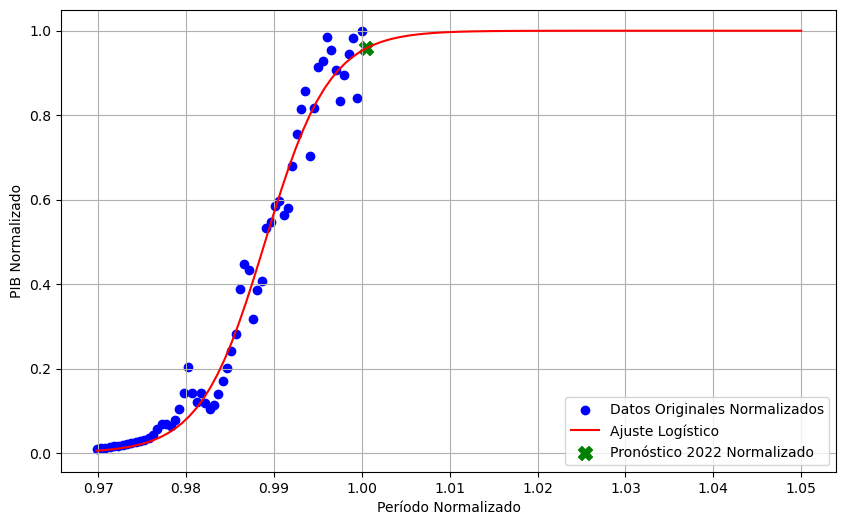

In [164]:
# Obtenemos el pronóstico para 2022 y aplicamos una desnormalización para obtener los datos

# Primeor normalizamos el año 2022
X_2022_norm = 2022 / X_max
    
# Despues predecimoslos datos para 2022
Y_2022_norm = modelo_logistico_2p(X_2022_norm, beta1_est, beta2_est)
    
# Por ultimo desnormalizamos los valores para obtener el PIB real
GDP_2022_pronostico = Y_2022_norm * Y_max

print(f"PIB normalizado predicho: {Y_2022_norm:.4f}")
print(f"Pronostico para 2022: {GDP_2022_pronostico:,.2f} Billones")

# Creamos una visualización con las normalizaciones para tener una mejor compresión del valor obtenido
X_fit = np.linspace(X_norm.min(), X_norm.max() + 0.05, 100)
Y_fit = modelo_logistico_2p(X_fit, * parametros)
    
plt.figure(figsize=(10, 6))
plt.scatter(X_norm, Y_norm, label='Datos Originales Normalizados', color='blue')
plt.plot(X_fit, Y_fit, color='red', label='Ajuste Logístico')
plt.scatter(X_2022_norm, Y_2022_norm, color='green', marker='X', s=100, label='Pronóstico 2022 Normalizado')
plt.xlabel('Período Normalizado')
plt.ylabel('PIB Normalizado')
plt.legend()
plt.grid(True)
plt.show()
